# 📊 Model Evaluation & Metrics Dashboard

Comprehensive evaluation of trained RL models for music recommendation.

---

In [1]:
# Setup and Imports
import sys
import os
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
os.chdir(project_root)  # Change working directory to project root

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.notebook import tqdm
from IPython.display import display, HTML, Markdown
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Custom color palette
COLORS = {
    'primary': '#667eea',
    'secondary': '#764ba2',
    'success': '#2ecc71',
    'danger': '#e74c3c',
    'warning': '#f39c12',
    'info': '#3498db'
}

print("✅ Imports successful!")
print(f"📁 Project root: {project_root}")
print(f"📁 Working directory: {Path.cwd()}")

✅ Imports successful!
📁 Project root: c:\Users\amine\Documents\ACADEMIC\MUSIQ
📁 Working directory: c:\Users\amine\Documents\ACADEMIC\MUSIQ


## 1. Load Models and Environment

---

In [2]:
from src.config.base_config import Config
from src.envs.music_env import MusicEnv
from src.agents.sac_agent import SACAgent
from src.agents.cql_agent import CQLAgent

# Available models to evaluate
MODELS = {
    'SAC': {
        'config': 'config/sac_config.yaml',
        'checkpoint': 'checkpoints/sac_experiment/best_model.agent.pt',
        'agent_class': SACAgent,
        'color': COLORS['primary']
    },
    'CQL': {
        'config': 'config/cql_config.yaml',
        'checkpoint': 'checkpoints/cql_experiment/best_model.agent.pt',
        'agent_class': CQLAgent,
        'color': COLORS['secondary']
    }
}

# Evaluation parameters
NUM_EVAL_EPISODES = 50
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"🔍 Models to evaluate: {list(MODELS.keys())}")
print(f"📊 Evaluation episodes: {NUM_EVAL_EPISODES}")
print(f"💻 Device: {device}")

🔍 Models to evaluate: ['SAC', 'CQL']
📊 Evaluation episodes: 50
💻 Device: cpu


In [3]:
def load_model(model_name, model_info, device='cpu'):
    """Load a model with its config"""
    config_path = Path(model_info['config'])
    checkpoint_path = Path(model_info['checkpoint'])
    
    if not checkpoint_path.exists():
        print(f"⚠️ Checkpoint not found: {checkpoint_path}")
        return None, None, None
    
    # Load config
    config = Config.from_yaml(str(config_path))
    
    # Create environment (data_path is relative to project root which is now cwd)
    env = MusicEnv(
        data_path=config.env.data_path,
        mode=config.env.mode,
        max_session_length=config.env.max_session_length,
        num_recent_tracks=config.env.num_recent_tracks,
        user_embed_dim=config.env.user_embed_dim,
        song_embed_dim=config.env.song_embed_dim
    )
    
    # Get dimensions
    if len(env.observation_space.shape) > 1:
        state_dim = env.observation_space.shape[1]
    else:
        state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0] if hasattr(env.action_space, 'shape') else env.action_space.n
    
    # Create agent
    agent_config = config.get_agent_config()
    agent = model_info['agent_class'](
        state_dim=state_dim,
        action_dim=action_dim,
        learning_rate=agent_config.learning_rate,
        gamma=agent_config.gamma,
        tau=agent_config.tau,
        alpha=agent_config.alpha,
        automatic_entropy_tuning=agent_config.automatic_entropy_tuning,
        batch_size=agent_config.batch_size,
        buffer_size=agent_config.buffer_size,
        network_config=agent_config.network_config.model_dump(),
        device=device
    )
    
    # Load checkpoint
    agent.load(str(checkpoint_path))
    agent.eval_mode()
    
    print(f"✅ Loaded {model_name}: {checkpoint_path.name}")
    return agent, env, config

# Load all models
loaded_models = {}
for name, info in MODELS.items():
    agent, env, config = load_model(name, info, device)
    if agent is not None:
        loaded_models[name] = {'agent': agent, 'env': env, 'config': config, **info}

15:04:04 | INFO     | Initializing MusicEnv in continuous mode
15:04:04 | INFO     | Data path: data\raw
15:04:04 | INFO     | Loading datasets...
15:04:05 | INFO     | Loaded 20778 songs
15:04:05 | INFO     | Extracted song embeddings: (20778, 8)
15:04:05 | WARNING  | Interactions file not found, will use synthetic user behavior
15:04:05 | INFO     | Extracted 6 song features
15:04:05 | INFO     | Normalized song features
15:04:05 | INFO     | Generating user embeddings from listening history...
15:04:05 | WARNING  | Generated 1000 synthetic users
15:04:05 | INFO     | Normalized embeddings
15:04:05 | INFO     | Continuous action space: 8-dim
15:04:05 | INFO     | Observation space: 76-dim
15:04:05 | SUCCESS  | MusicEnv initialized successfully
15:04:05 | INFO     | Initialized SACAgent | State dim: 76 | Action dim: 8 | Device: cpu
15:04:10 | SUCCESS  | SAC Agent initialized | Auto entropy: True | Buffer size: 1,000,000
15:04:10 | INFO     | Loaded SAC checkpoint from checkpoints\sac_

## 2. Evaluation Metrics

---

In [4]:
def calculate_diversity(song_indices, song_embeddings):
    """Calculate intra-list diversity using cosine distance"""
    if len(song_indices) < 2:
        return 0.0
    
    embeddings = song_embeddings[song_indices]
    sim_matrix = cosine_similarity(embeddings)
    
    # Get average pairwise similarity (excluding diagonal)
    n = len(song_indices)
    avg_sim = (sim_matrix.sum() - n) / (n * (n - 1)) if n > 1 else 0
    
    # Diversity = 1 - similarity
    return 1 - avg_sim

def calculate_coverage(song_indices, total_songs):
    """Calculate catalog coverage (% of unique songs recommended)"""
    unique_songs = len(set(song_indices))
    return unique_songs / total_songs

def calculate_serendipity(song_indices, user_embedding, song_embeddings):
    """Calculate serendipity (relevant but unexpected recommendations)"""
    if len(song_indices) == 0:
        return 0.0
    
    # Truncate to same dimension
    min_dim = min(len(user_embedding), song_embeddings.shape[1])
    user_emb = user_embedding[:min_dim].reshape(1, -1)
    song_embs = song_embeddings[song_indices, :min_dim]
    
    # Relevance (similarity to user)
    relevance = cosine_similarity(user_emb, song_embs)[0]
    
    # Unexpectedness (dissimilarity between consecutive songs)
    unexpectedness = []
    for i in range(1, len(song_indices)):
        sim = cosine_similarity(
            song_embs[i-1:i], 
            song_embs[i:i+1]
        )[0, 0]
        unexpectedness.append(1 - sim)
    
    if unexpectedness:
        avg_unexpectedness = np.mean(unexpectedness)
    else:
        avg_unexpectedness = 0
    
    # Serendipity = relevance * unexpectedness
    return np.mean(relevance) * avg_unexpectedness

In [5]:
def evaluate_model(agent, env, num_episodes=50, pbar_desc="Evaluating"):
    """Comprehensive model evaluation"""
    results = {
        'episode_rewards': [],
        'episode_lengths': [],
        'skip_rates': [],
        'partial_rates': [],
        'full_rates': [],
        'diversity_scores': [],
        'serendipity_scores': [],
        'all_song_indices': []
    }
    
    for episode in tqdm(range(num_episodes), desc=pbar_desc):
        state, info = env.reset()
        user_idx = info['user_idx']
        user_embedding = env.user_embeddings[user_idx]
        
        episode_reward = 0
        reactions = []
        song_indices = []
        
        terminated = False
        truncated = False
        
        while not (terminated or truncated):
            action = agent.act(state, training=False)
            next_state, reward, terminated, truncated, step_info = env.step(action)
            
            episode_reward += reward
            reactions.append(step_info['user_reaction'])
            song_indices.append(step_info['song_idx'])
            
            state = next_state
        
        # Calculate metrics
        results['episode_rewards'].append(episode_reward)
        results['episode_lengths'].append(len(reactions))
        results['skip_rates'].append(reactions.count(0) / len(reactions) if reactions else 0)
        results['partial_rates'].append(reactions.count(1) / len(reactions) if reactions else 0)
        results['full_rates'].append(reactions.count(2) / len(reactions) if reactions else 0)
        results['diversity_scores'].append(calculate_diversity(song_indices, env.song_embeddings))
        results['serendipity_scores'].append(calculate_serendipity(song_indices, user_embedding, env.song_embeddings))
        results['all_song_indices'].extend(song_indices)
    
    # Calculate aggregate metrics
    results['coverage'] = calculate_coverage(results['all_song_indices'], len(env.songs_df))
    
    return results

In [6]:
# Evaluate all models
evaluation_results = {}

for name, model_data in loaded_models.items():
    print(f"\n🔍 Evaluating {name}...")
    results = evaluate_model(
        model_data['agent'], 
        model_data['env'], 
        num_episodes=NUM_EVAL_EPISODES,
        pbar_desc=f"Evaluating {name}"
    )
    evaluation_results[name] = results
    
print("\n✅ Evaluation complete!")


🔍 Evaluating SAC...


Evaluating SAC:   0%|          | 0/50 [00:00<?, ?it/s]

15:04:20 | INFO     | Episode ended (natural) | User: user_770 | Length: 6 | Total reward: 5.66 | Avg reward: 0.944 | Skip rate: 16.67% | Completion rate: 50.00%
15:04:21 | INFO     | Episode ended (natural) | User: user_435 | Length: 9 | Total reward: 8.94 | Avg reward: 0.993 | Skip rate: 0.00% | Completion rate: 66.67%
15:04:21 | INFO     | Episode ended (natural) | User: user_924 | Length: 16 | Total reward: 9.41 | Avg reward: 0.588 | Skip rate: 18.75% | Completion rate: 25.00%
15:04:21 | INFO     | Episode ended (natural) | User: user_615 | Length: 16 | Total reward: 11.35 | Avg reward: 0.710 | Skip rate: 12.50% | Completion rate: 25.00%
15:04:22 | INFO     | Episode ended (truncated) | User: user_360 | Length: 20 | Total reward: 18.42 | Avg reward: 0.921 | Skip rate: 0.00% | Completion rate: 45.00%
15:04:22 | INFO     | Episode ended (natural) | User: user_157 | Length: 19 | Total reward: 4.89 | Avg reward: 0.257 | Skip rate: 52.63% | Completion rate: 0.00%
15:04:23 | INFO     | E

Evaluating CQL:   0%|          | 0/50 [00:00<?, ?it/s]

15:04:36 | INFO     | Episode ended (truncated) | User: user_999 | Length: 20 | Total reward: 11.03 | Avg reward: 0.551 | Skip rate: 30.00% | Completion rate: 40.00%
15:04:36 | INFO     | Episode ended (truncated) | User: user_156 | Length: 20 | Total reward: 6.08 | Avg reward: 0.304 | Skip rate: 40.00% | Completion rate: 15.00%
15:04:36 | INFO     | Episode ended (natural) | User: user_894 | Length: 5 | Total reward: -1.29 | Avg reward: -0.257 | Skip rate: 80.00% | Completion rate: 0.00%
15:04:37 | INFO     | Episode ended (truncated) | User: user_974 | Length: 20 | Total reward: 16.40 | Avg reward: 0.820 | Skip rate: 10.00% | Completion rate: 45.00%
15:04:37 | INFO     | Episode ended (natural) | User: user_179 | Length: 8 | Total reward: 7.70 | Avg reward: 0.963 | Skip rate: 0.00% | Completion rate: 62.50%
15:04:37 | INFO     | Episode ended (natural) | User: user_482 | Length: 7 | Total reward: 1.22 | Avg reward: 0.174 | Skip rate: 42.86% | Completion rate: 0.00%
15:04:37 | INFO   

## 3. Results Dashboard

---

In [7]:
# Create summary dataframe
summary_data = []

for name, results in evaluation_results.items():
    summary_data.append({
        'Model': name,
        'Mean Reward': np.mean(results['episode_rewards']),
        'Std Reward': np.std(results['episode_rewards']),
        'Mean Length': np.mean(results['episode_lengths']),
        'Skip Rate (%)': np.mean(results['skip_rates']) * 100,
        'Full Rate (%)': np.mean(results['full_rates']) * 100,
        'Diversity': np.mean(results['diversity_scores']),
        'Serendipity': np.mean(results['serendipity_scores']),
        'Coverage (%)': results['coverage'] * 100
    })

summary_df = pd.DataFrame(summary_data)

# Display styled summary
print("\n📊 EVALUATION SUMMARY")
print("=" * 80)
display(
    summary_df.style
    .format({
        'Mean Reward': '{:.2f}',
        'Std Reward': '{:.2f}',
        'Mean Length': '{:.1f}',
        'Skip Rate (%)': '{:.1f}%',
        'Full Rate (%)': '{:.1f}%',
        'Diversity': '{:.3f}',
        'Serendipity': '{:.4f}',
        'Coverage (%)': '{:.2f}%'
    })
    .background_gradient(subset=['Mean Reward', 'Full Rate (%)', 'Diversity'], cmap='Greens')
    .background_gradient(subset=['Skip Rate (%)'], cmap='Reds_r')
    .set_properties(**{'text-align': 'center'})
)


📊 EVALUATION SUMMARY


,Model,Mean Reward,Std Reward,Mean Length,Skip Rate (%),Full Rate (%),Diversity,Serendipity,Coverage (%)
0,SAC,8.12,5.59,11.1,19.3%,41.6%,0.272,0.1266,1.71%
1,CQL,6.21,5.41,10.5,22.2%,30.6%,0.097,0.0356,1.21%


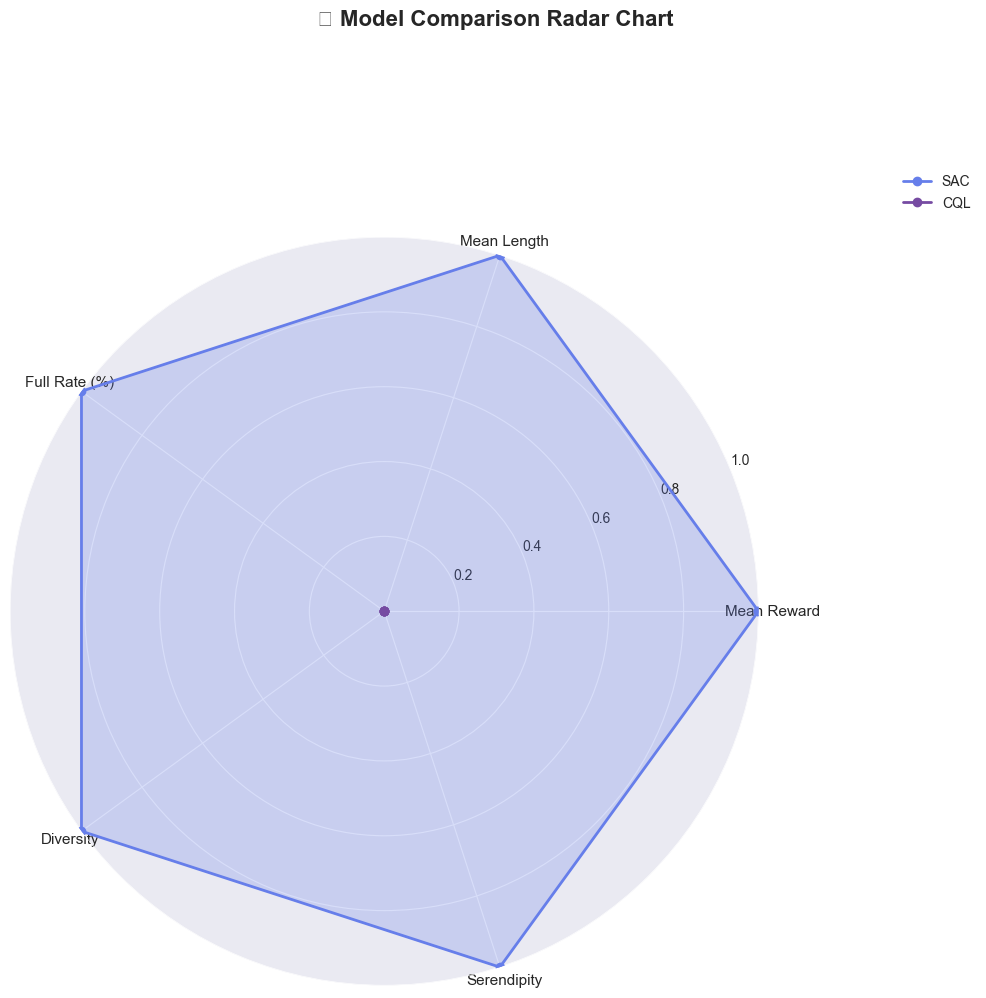

In [8]:
# Radar chart for model comparison
from math import pi

def create_radar_chart(summary_df, colors):
    # Normalize metrics to 0-1 scale for radar chart
    metrics = ['Mean Reward', 'Mean Length', 'Full Rate (%)', 'Diversity', 'Serendipity']
    
    # Normalize each metric
    normalized_data = {}
    for metric in metrics:
        max_val = summary_df[metric].max()
        min_val = summary_df[metric].min()
        if max_val == min_val:
            normalized_data[metric] = [0.5] * len(summary_df)
        else:
            normalized_data[metric] = [(v - min_val) / (max_val - min_val) for v in summary_df[metric]]
    
    # Number of variables
    num_vars = len(metrics)
    angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
    angles += angles[:1]  # Complete the loop
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    fig.suptitle('🎯 Model Comparison Radar Chart', fontsize=16, fontweight='bold', y=1.05)
    
    for idx, model in enumerate(summary_df['Model']):
        values = [normalized_data[m][idx] for m in metrics]
        values += values[:1]  # Complete the loop
        
        color = colors.get(model, COLORS['info'])
        ax.plot(angles, values, 'o-', linewidth=2, label=model, color=color)
        ax.fill(angles, values, alpha=0.25, color=color)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=11)
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    
    plt.tight_layout()
    return fig

model_colors = {name: info['color'] for name, info in loaded_models.items()}
fig = create_radar_chart(summary_df, model_colors)
plt.savefig('plots/model_comparison_radar.png', dpi=150, bbox_inches='tight')
plt.show()

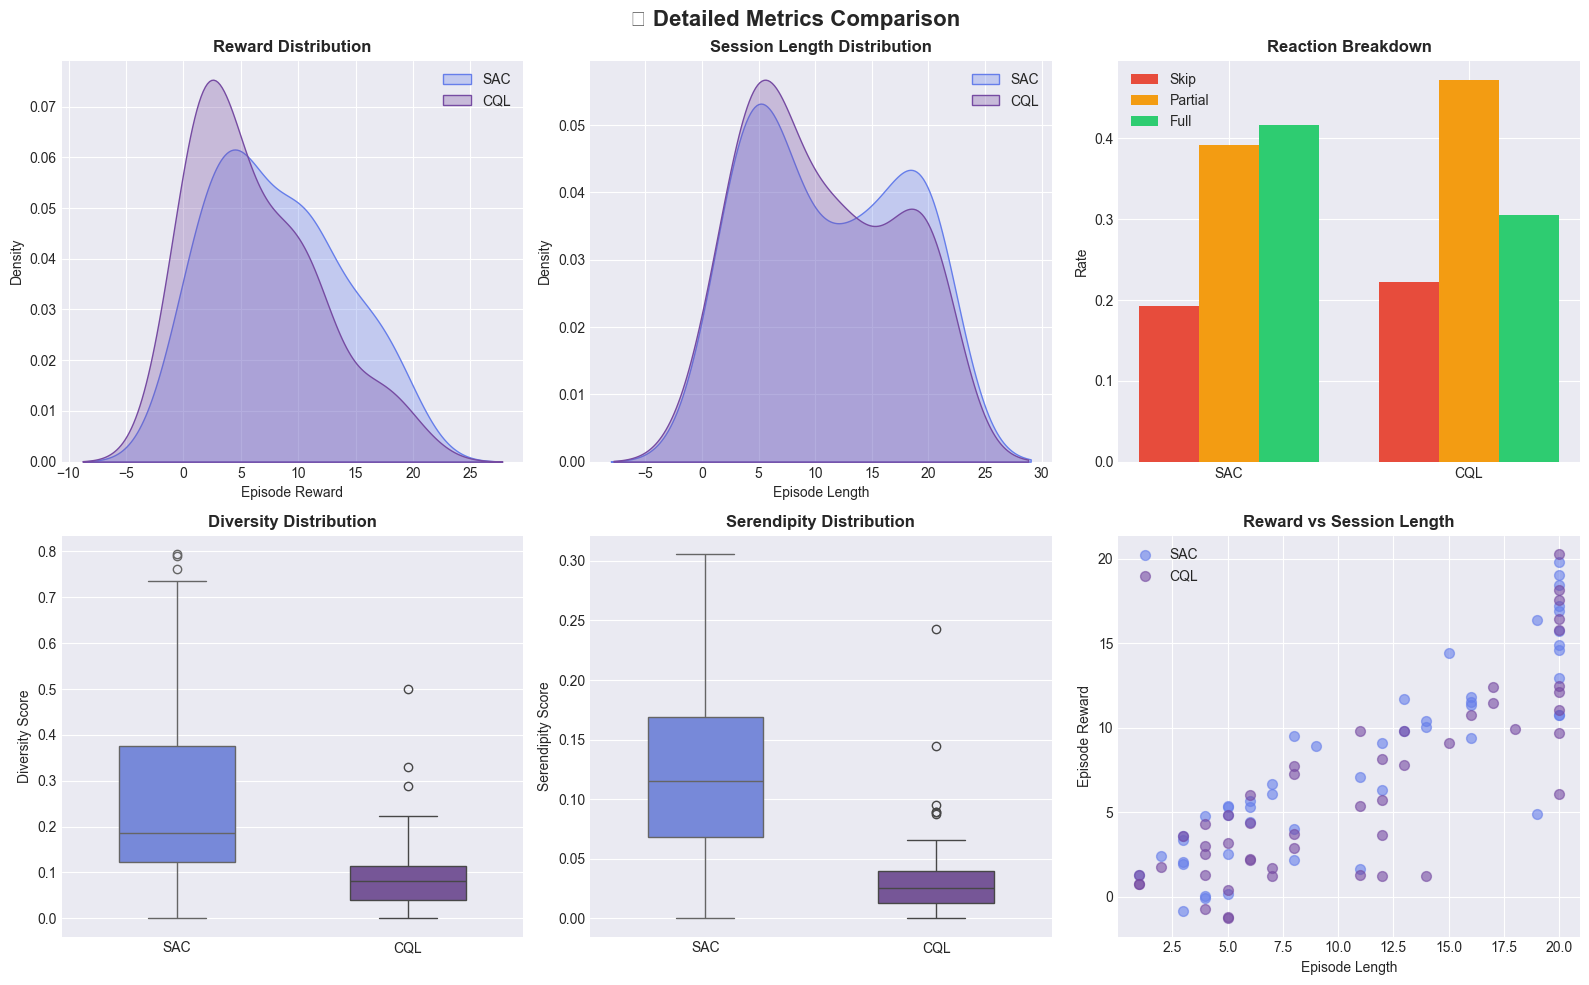

In [9]:
# Detailed metrics visualization
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('📈 Detailed Metrics Comparison', fontsize=16, fontweight='bold')

# 1. Reward Distribution
ax1 = axes[0, 0]
for name, results in evaluation_results.items():
    color = loaded_models[name]['color']
    sns.kdeplot(results['episode_rewards'], ax=ax1, label=name, color=color, fill=True, alpha=0.3)
ax1.set_title('Reward Distribution', fontweight='bold')
ax1.set_xlabel('Episode Reward')
ax1.legend()

# 2. Session Length Distribution
ax2 = axes[0, 1]
for name, results in evaluation_results.items():
    color = loaded_models[name]['color']
    sns.kdeplot(results['episode_lengths'], ax=ax2, label=name, color=color, fill=True, alpha=0.3)
ax2.set_title('Session Length Distribution', fontweight='bold')
ax2.set_xlabel('Episode Length')
ax2.legend()

# 3. Reaction Breakdown
ax3 = axes[0, 2]
x = np.arange(len(evaluation_results))
width = 0.25
skip_rates = [np.mean(r['skip_rates']) for r in evaluation_results.values()]
partial_rates = [np.mean(r['partial_rates']) for r in evaluation_results.values()]
full_rates = [np.mean(r['full_rates']) for r in evaluation_results.values()]

ax3.bar(x - width, skip_rates, width, label='Skip', color=COLORS['danger'])
ax3.bar(x, partial_rates, width, label='Partial', color=COLORS['warning'])
ax3.bar(x + width, full_rates, width, label='Full', color=COLORS['success'])
ax3.set_title('Reaction Breakdown', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(evaluation_results.keys())
ax3.set_ylabel('Rate')
ax3.legend()

# 4. Diversity Scores
ax4 = axes[1, 0]
for name, results in evaluation_results.items():
    color = loaded_models[name]['color']
    sns.boxplot(x=[name]*len(results['diversity_scores']), y=results['diversity_scores'], 
                ax=ax4, color=color, width=0.5)
ax4.set_title('Diversity Distribution', fontweight='bold')
ax4.set_ylabel('Diversity Score')

# 5. Serendipity Scores
ax5 = axes[1, 1]
for name, results in evaluation_results.items():
    color = loaded_models[name]['color']
    sns.boxplot(x=[name]*len(results['serendipity_scores']), y=results['serendipity_scores'], 
                ax=ax5, color=color, width=0.5)
ax5.set_title('Serendipity Distribution', fontweight='bold')
ax5.set_ylabel('Serendipity Score')

# 6. Reward vs Length Scatter
ax6 = axes[1, 2]
for name, results in evaluation_results.items():
    color = loaded_models[name]['color']
    ax6.scatter(results['episode_lengths'], results['episode_rewards'], 
                label=name, color=color, alpha=0.6, s=50)
ax6.set_title('Reward vs Session Length', fontweight='bold')
ax6.set_xlabel('Episode Length')
ax6.set_ylabel('Episode Reward')
ax6.legend()

plt.tight_layout()
plt.savefig('plots/detailed_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Statistical Analysis

---

In [10]:
from scipy import stats

def perform_statistical_tests(evaluation_results):
    """Perform statistical tests between models"""
    model_names = list(evaluation_results.keys())
    
    if len(model_names) < 2:
        print("⚠️ Need at least 2 models for comparison")
        return None
    
    results = []
    metrics = ['episode_rewards', 'episode_lengths', 'skip_rates', 'full_rates', 'diversity_scores']
    
    for metric in metrics:
        for i, name1 in enumerate(model_names):
            for name2 in model_names[i+1:]:
                data1 = evaluation_results[name1][metric]
                data2 = evaluation_results[name2][metric]
                
                # Perform t-test
                t_stat, p_value = stats.ttest_ind(data1, data2)
                
                # Effect size (Cohen's d)
                pooled_std = np.sqrt((np.std(data1)**2 + np.std(data2)**2) / 2)
                cohens_d = (np.mean(data1) - np.mean(data2)) / pooled_std if pooled_std > 0 else 0
                
                results.append({
                    'Metric': metric.replace('_', ' ').title(),
                    'Model 1': name1,
                    'Model 2': name2,
                    'Mean 1': np.mean(data1),
                    'Mean 2': np.mean(data2),
                    'T-Statistic': t_stat,
                    'P-Value': p_value,
                    "Cohen's d": cohens_d,
                    'Significant': '✅' if p_value < 0.05 else '❌'
                })
    
    return pd.DataFrame(results)

if len(evaluation_results) >= 2:
    stats_df = perform_statistical_tests(evaluation_results)
    
    print("\n📊 Statistical Comparison")
    print("=" * 80)
    display(
        stats_df.style
        .format({
            'Mean 1': '{:.3f}',
            'Mean 2': '{:.3f}',
            'T-Statistic': '{:.3f}',
            'P-Value': '{:.4f}',
            "Cohen's d": '{:.3f}'
        })
        .applymap(lambda x: 'background-color: #d4edda' if x == '✅' else '', subset=['Significant'])
    )
else:
    print("⚠️ Need at least 2 models for statistical comparison")


📊 Statistical Comparison


,Metric,Model 1,Model 2,Mean 1,Mean 2,T-Statistic,P-Value,Cohen's d,Significant
0,Episode Rewards,SAC,CQL,8.121,6.210,1.719,0.0887,0.347,❌
1,Episode Lengths,SAC,CQL,11.140,10.540,0.461,0.6458,0.093,❌
2,Skip Rates,SAC,CQL,0.193,0.222,-0.625,0.5334,-0.126,❌
3,Full Rates,SAC,CQL,0.416,0.306,2.060,0.0420,0.416,✅
4,Diversity Scores,SAC,CQL,0.272,0.097,5.311,0.0000,1.073,✅


## 5. Final Report

---

In [11]:
# Generate final report
print("\n" + "=" * 80)
print("📋 FINAL EVALUATION REPORT")
print("=" * 80)

# Find best model for each metric
metrics_to_check = {
    'Mean Reward': ('max', 'Higher is better'),
    'Skip Rate (%)': ('min', 'Lower is better'),
    'Full Rate (%)': ('max', 'Higher is better'),
    'Diversity': ('max', 'Higher is better'),
    'Serendipity': ('max', 'Higher is better')
}

print("\n🏆 Best Model per Metric:")
print("-" * 40)
for metric, (func, desc) in metrics_to_check.items():
    if func == 'max':
        best_idx = summary_df[metric].idxmax()
    else:
        best_idx = summary_df[metric].idxmin()
    best_model = summary_df.loc[best_idx, 'Model']
    best_value = summary_df.loc[best_idx, metric]
    
    if '%' in metric:
        print(f"   {metric}: {best_model} ({best_value:.1f}%) - {desc}")
    else:
        print(f"   {metric}: {best_model} ({best_value:.3f}) - {desc}")

# Overall recommendation
print("\n📌 Key Insights:")
print("-" * 40)

for name, results in evaluation_results.items():
    avg_reward = np.mean(results['episode_rewards'])
    skip_rate = np.mean(results['skip_rates'])
    full_rate = np.mean(results['full_rates'])
    diversity = np.mean(results['diversity_scores'])
    
    quality = "🟢 Good" if (avg_reward > 5 and full_rate > 0.4) else "🟡 Moderate" if avg_reward > 0 else "🔴 Needs Work"
    
    print(f"\n   {name}:")
    print(f"   └─ Overall Quality: {quality}")
    print(f"   └─ Engagement: {full_rate:.1%} full listens, {skip_rate:.1%} skips")
    print(f"   └─ Diversity: {diversity:.3f} (range 0-1)")

print("\n" + "=" * 80)
print("✅ Evaluation Complete!")
print("=" * 80)


📋 FINAL EVALUATION REPORT

🏆 Best Model per Metric:
----------------------------------------
   Mean Reward: SAC (8.121) - Higher is better
   Skip Rate (%): SAC (19.3%) - Lower is better
   Full Rate (%): SAC (41.6%) - Higher is better
   Diversity: SAC (0.272) - Higher is better
   Serendipity: SAC (0.127) - Higher is better

📌 Key Insights:
----------------------------------------

   SAC:
   └─ Overall Quality: 🟢 Good
   └─ Engagement: 41.6% full listens, 19.3% skips
   └─ Diversity: 0.272 (range 0-1)

   CQL:
   └─ Overall Quality: 🟡 Moderate
   └─ Engagement: 30.6% full listens, 22.2% skips
   └─ Diversity: 0.097 (range 0-1)

✅ Evaluation Complete!


In [12]:
# Save results to CSV
output_dir = Path('plots')
output_dir.mkdir(exist_ok=True)

summary_df.to_csv(output_dir / 'evaluation_summary.csv', index=False)
print(f"✅ Results saved to {output_dir / 'evaluation_summary.csv'}")

✅ Results saved to plots\evaluation_summary.csv
